# Tentando ler o sinal .mat gerado com faltas  

In [12]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftshift, fftfreq
from scipy.signal import find_peaks, windows
import math
from sklearn.linear_model import OrthogonalMatchingPursuit
import numpy as np
import pywt # PyWavelets
# import plotly.express as px

# %matplotlib widget

## Extraindo o sinal

In [13]:
mat_contents = sio.loadmat('/mnt/HD/HD/Documents/Mestrado/Dissertacao/compressive_sensing/learning_cs/FaltamonofasicaAT45km20ohm200khz.mat')

print(mat_contents.keys())

s1 = mat_contents['s1']
s2 = mat_contents['s2']
s3 = mat_contents['s3']
tempo = mat_contents['tempo'].flatten()


dict_keys(['__header__', '__version__', '__globals__', 'tempo', 's1', 's2', 's3'])


## Visualizando os sinais

As frequencias relevantes no intevalo de 0 e 150000 são:
[   480.02999311   5280.32992416  11040.68984142  16801.04975868
  22081.37968284  27841.7396001   33602.09951736  38882.42944152
  44642.78935878  50403.14927604  56163.5091933   61923.86911057
  67684.22902783  73444.58894509  79204.94886235  84965.30877961
  90725.66869688 102246.3885314  108006.74844866]


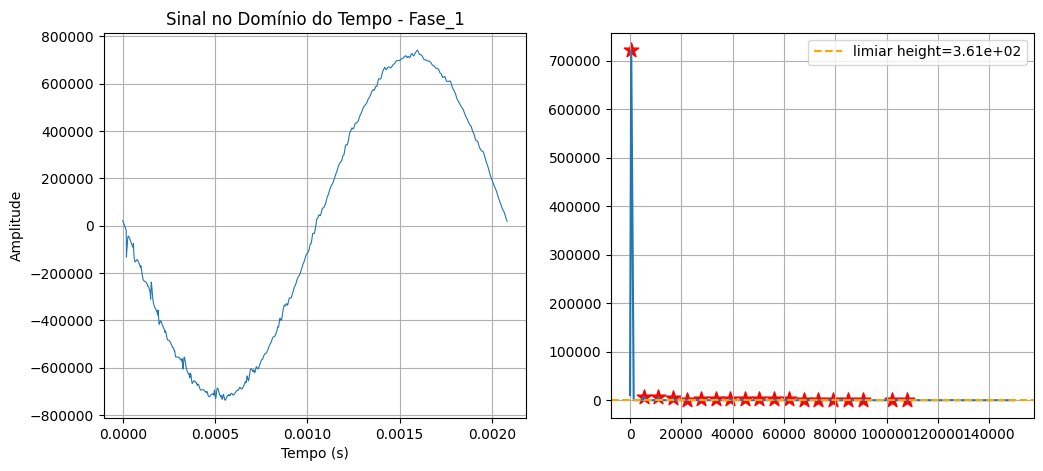

As frequencias relevantes no intevalo de 0 e 150000 são:
[  480.02999311  5280.32992416 11040.68984142 16801.04975868
 22081.37968284 27841.7396001  33602.09951736 38882.42944152
 44642.78935878 50403.14927604 56163.5091933  61923.86911057
 67684.22902783 79204.94886235 84965.30877961]


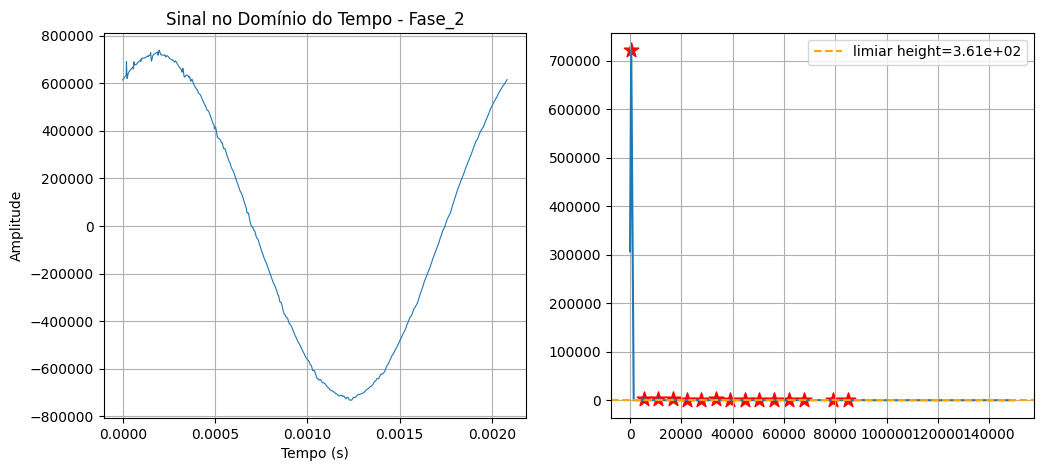

As frequencias relevantes no intevalo de 0 e 150000 são:
[  480.02999311  5280.32992416 11040.68984142 16801.04975868
 22081.37968284 27841.7396001  33602.09951736 38882.42944152
 44642.78935878 50403.14927604 56163.5091933  61923.86911057
 67684.22902783 79204.94886235 84965.30877961]


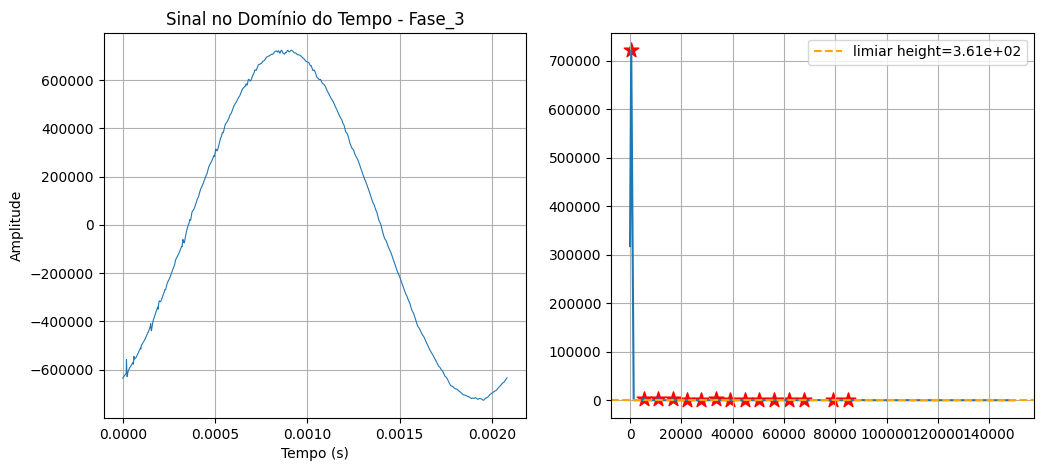

In [14]:
# seus sinais: sinal (1D numpy)
# tempo vetores: tempo_sinal já ok
dt = np.mean(np.diff(tempo))  # ou use seu dt já calculado
Fs = 1.0 / dt


def analyze_and_plot(sinal, tempo, nome, apply_window=True, peak_rel_threshold=0.05):
    N = len(sinal)
    # 1) remover média para eliminar DC indesejado (opcional)
    sinal_zero_mean = sinal - np.mean(sinal)

    # 2) aplicar janela para reduzir leakage (opcional)
    if apply_window:
        win = windows.hann(N)
        sinal_win = sinal_zero_mean * win
        # correção de amplitude pela janela (normalizar energia)
        coherent_gain = np.sum(win) / N
    else:
        sinal_win = sinal_zero_mean
        coherent_gain = 1.0

    # 3) FFT unilateral (apenas frequências >=0)
    fft_vals = np.fft.rfft(sinal_win)
    freqs = np.fft.rfftfreq(N, d=dt)  # d = dt é claro e simples

    # 4) magnitude e normalização
    mag = np.abs(fft_vals) / N  # normaliza por N
    # multiplicar por 2 para recuperar energia do lado negativo (exceto DC e Nyquist)
    mag[1:-1] *= 2.0
    # compensar ganho da janela
    mag /= coherent_gain

    # 5) plot domínio do tempo e espectro (linear e em dB)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(tempo, sinal, linewidth=0.8)
    plt.title(f"Sinal no Domínio do Tempo - {nome}")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.grid()

    # 6) detectar picos significativos

    # Ajustando a janela de frequencias à analisar (remover DC -> Hz)
    fmin, fmax = 0, 150000
    mask = (freqs >= fmin) & (freqs <= fmax)
    freqs_sel = freqs[mask]
    mag_sel = mag[mask]
    
    # limiar relativo (ex.: 5% do máximo dentro da faixa selecionada)
    rel_height = 0.0005 * np.max(mag_sel)
    
    # Busque os picos apenas no intervalo de fmin, fmax
    peaks, props = find_peaks(mag_sel, height=rel_height, prominence=0.00000002*np.max(mag_sel))
    
    # Converter para frequencias reais
    peak_freqs = freqs_sel[peaks]
    peak_mags = mag_sel[peaks]
    
    print(f"As frequencias relevantes no intevalo de {fmin} e {fmax} são:")
    print(peak_freqs)
    
    # Plotando as frequencias
    # plt.subplot(1, 2, 2)
    # plt.plot(freqs_sel, mag_sel, linewidth=0.8)
    # plt.scatter(peak_freqs, peak_mags, color="red", marker="*", s=100, label="Picos")
    # plt.title(f"Espectro Unilateral - {nome}")
    # plt.xlabel("Frequência (Hz)")
    # plt.ylabel("Magnitude (linear)")
    # plt.legend()
    # plt.grid()
    # plt.tight_layout()
    
    # plt.figure(figsize=(10,4))
    plt.subplot(1,2,2)
    plt.plot(freqs_sel, mag_sel)
    plt.axhline(rel_height, color='orange', linestyle='--', label=f"limiar height={rel_height:.2e}")
    plt.scatter(freqs_sel[peaks], mag_sel[peaks], color='red', marker='*', s=120)
    plt.legend()
    plt.grid()
    plt.show()

    return freqs, mag, peak_freqs, peak_mags

# exemplo de uso para cada sinal (assumindo signals e nomes definidos)
informacoes_sinais = {}
signals = [s1[:,0], s2[:,0], s3[:,0]]
for i, sinal in enumerate(signals):
    N = len(sinal)
    tempo_sinal = np.arange(N) * dt
    freqs, mag, peak_freqs, peak_mags = analyze_and_plot(
        sinal, tempo_sinal, f"Fase_{i+1}", apply_window=True, peak_rel_threshold=0.05
    )
    i_sinal = {
        "sinal_ch1": sinal,
        "freqs": freqs,
        "mag": mag,
        "peak_freqs": peak_freqs,
        "peak_mags": peak_mags
    }
    informacoes_sinais[f"Fase_{i+1}"] = i_sinal
    
# TODO: Adicionar frequencia de 60 Hz nas frequencias principais - isso pode estar causando o erro na reconstrução

## Determinando o tamanho ideal da amostra M

In [15]:
S = len(informacoes_sinais['Fase_1']['peak_freqs'])+1
N = len(informacoes_sinais['Fase_1']['sinal_ch1'])
print(f"S = {S}")
print(f"N = {N}")
C = 1.5

M = round(C*S*math.log10(N/S))
print(f"M = {M}")

S = 20
N = 3334
M = 67


## Calculando diferentes matrizes de phi

In [16]:
# phi_gaussiana = np.random.normal(size=(M,N))
# Normalização de phi
phi_gaussiana = np.random.randn(M, N) 
phi_gaussiana = phi_gaussiana / np.sqrt(N)

phi_bernoulli = np.random.choice([1/(math.sqrt(M)), -1/(math.sqrt(M))], size=(M,N))

## Amostragem esparsa do sinal

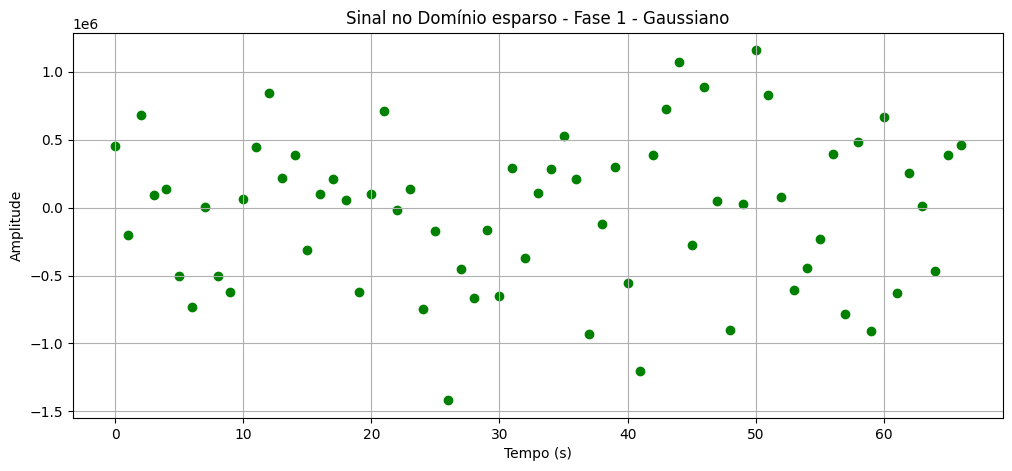

In [17]:
y_gaussiano = phi_gaussiana@informacoes_sinais['Fase_1']['sinal_ch1']

plt.figure(figsize=(12, 5))
plt.scatter(np.arange(len(y_gaussiano)),y_gaussiano, color='green', marker='o')
plt.title(f"Sinal no Domínio esparso - Fase 1 - Gaussiano")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

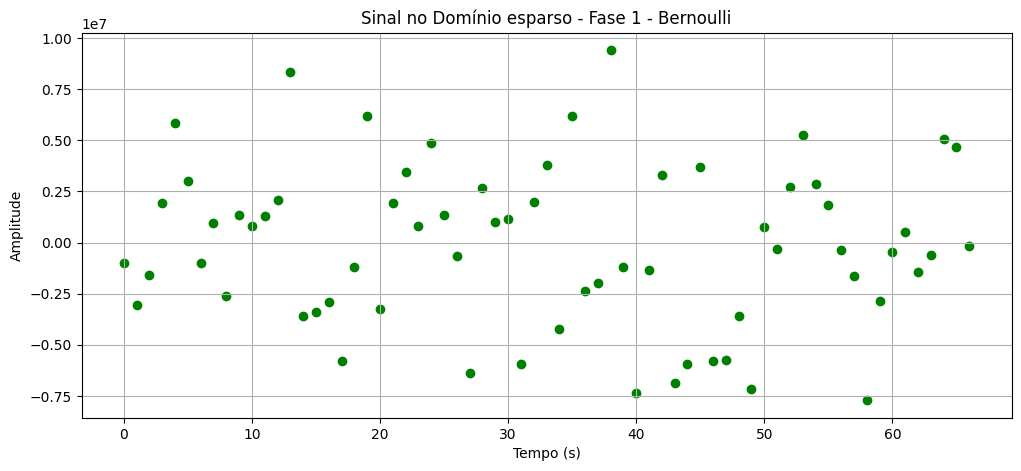

In [18]:
y_bernoulli = phi_bernoulli@informacoes_sinais['Fase_1']['sinal_ch1']

plt.figure(figsize=(12, 5))
plt.scatter(np.arange(len(y_bernoulli)),y_bernoulli, color='green', marker='o')
plt.title(f"Sinal no Domínio esparso - Fase 1 - Bernoulli")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

## Obtendo a matriz Psi para o cálculo de A

In [19]:


# 2. Escolha a família e o nível da Wavelet (Crucial para a esparsidade)
wavelet_name = 'db4' # Exemplo de Daubechies (comum para sinais elétricos)
level = 4              # Nível de decomposição

# Função auxiliar para simular a matriz Psi (IDWT)
def build_wavelet_matrix(N, wavelet_name, level):
    # Encontra o tamanho do vetor de coeficientes (s) para o nível e wavelet escolhidos
    coeffs_length = 0
    temp_s = np.zeros(N)
    
    # Aplica a DWT para descobrir a dimensão exata do vetor s
    coeffs = pywt.wavedec(temp_s, wavelet_name, level=level)
    coeffs_length = sum(len(c) for c in coeffs)
    
    Psi = np.zeros((N, coeffs_length))
    
    # Preenche a matriz Psi aplicando a IDWT a vetores base (coluna a coluna)
    for i in range(coeffs_length):
        # 1. Cria um vetor s base (impulso na posição i)
        s_base = list(coeffs)
        current_idx = 0
        
        # Encontra em qual banda (approximation ou details) o índice 'i' cai
        for j, c in enumerate(s_base):
            band_len = len(c)
            if i < current_idx + band_len:
                # Cria um vetor de zeros para a banda e seta 1 na posição correta
                new_c = np.zeros_like(c)
                new_c[i - current_idx] = 1.0
                s_base[j] = new_c
                break
            current_idx += band_len
            
        # 2. Aplica a IDWT (IDWT) para obter a coluna i da matriz Psi
        Psi[:, i] = pywt.waverec(s_base, wavelet_name)
    
    return Psi, coeffs_length

Psi, N_sparse = build_wavelet_matrix(N, wavelet_name, level)
# Nota: N_sparse será ligeiramente diferente de N, mas será a dimensão de s

## Reconstrução do sinal esparso usando a phi gaussiano

### Calculando S (esparsidade)

In [20]:
# 1. Transforme o sinal original (x) para o domínio esparso (s_original)
# Adapte esta parte para a sua estrutura de pywt.wavedec (que retorna uma lista de coeficientes)
s_coeffs_original = pywt.wavedec(sinal, wavelet_name, level=level)
s_flat_original = np.concatenate([c.flatten() for c in s_coeffs_original])

# 2. Encontre S baseado na energia
# Defina um limite (threshold) que represente S% da energia
threshold_ratio = 0.95  # Ex: 99% da energia

# Coeficientes ordenados pelo valor absoluto
s_sorted = np.sort(np.abs(s_flat_original))[::-1] 
cumulative_energy = np.cumsum(s_sorted**2)
total_energy = cumulative_energy[-1]

# Encontre o índice S onde a energia acumulada atinge threshold_ratio
S_calculado = np.argmax(cumulative_energy >= threshold_ratio * total_energy) + 1

### Abordagem de reconstrução usando a matriz gaussiana

/mnt/HD/HD/Documents/Mestrado/Dissertacao/compressive_sensing/.venv/lib/python3.11/site-packages/sklearn/linear_model/_omp.py:445: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  out = _cholesky_omp(


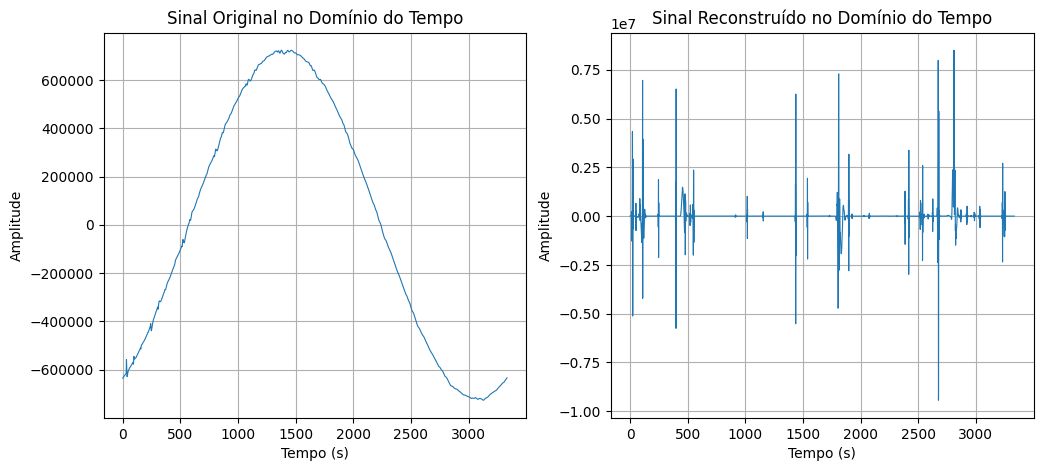

In [21]:
# Calcular a Matriz de Sensing A
A = phi_gaussiana @ Psi
# A tem dimensão (M x N_sparse)

# S = int(0.1*N)# Chute de esparsidade -> S refere-se ao número de coeficientes Wavelet grandes
omp = OrthogonalMatchingPursuit(n_nonzero_coefs=S_calculado)
omp.fit(A,y_gaussiano)
s_reconstruido_flat = omp.coef_

# Reconstruindo o sinal
# 1. Reestruturar s_reconstruido_flat (vetor plano) na estrutura de coeficientes Wavelet (lista de arrays)
s_reconstruido_coeffs = []
current_idx = 0

# A estrutura deve ser a mesma obtida ao aplicar pywt.wavedec em um vetor de zeros
temp_s = np.zeros(N)
example_coeffs = pywt.wavedec(temp_s, wavelet_name, level=level)

for c in example_coeffs:
    band_len = len(c)
    # Extrai o segmento de s_reconstruido_flat correspondente à banda
    s_reconstruido_coeffs.append(s_reconstruido_flat[current_idx : current_idx + band_len])
    current_idx += band_len

# 2. Aplicar a Transformada Wavelet Inversa (IDWT)
x_reconstruido = pywt.waverec(s_reconstruido_coeffs, wavelet_name)

# 3. Comparar o resultado
# x_reconstruido é o seu sinal elétrico reconstruído com base nas suas poucas medições (y).
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.arange(N), sinal, linewidth=0.8)
# plt.plot(np.arange(N), x_reconstruido, color='r', linewidth=0.8)
plt.title(f"Sinal Original no Domínio do Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(1,2,2)
plt.plot(np.arange(N), x_reconstruido, linewidth=0.8)
plt.title(f"Sinal Reconstruído no Domínio do Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.show()

### Abordagem de reconstrução usando phi de bernoulli

/mnt/HD/HD/Documents/Mestrado/Dissertacao/compressive_sensing/.venv/lib/python3.11/site-packages/sklearn/linear_model/_omp.py:445: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  out = _cholesky_omp(


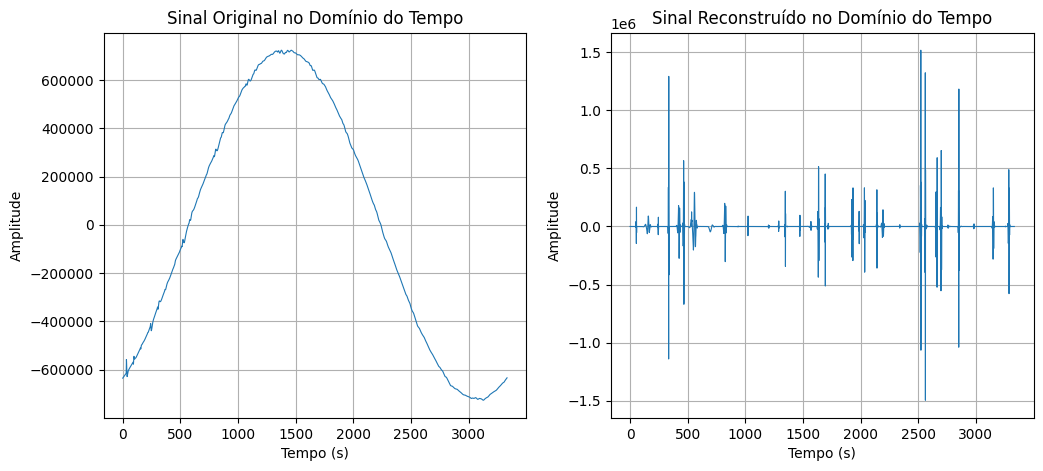

In [22]:
# Calcular a Matriz de Sensing A
A = phi_bernoulli @ Psi
# A tem dimensão (M x N_sparse)

# S = int(0.1*N)# Chute de esparsidade -> S refere-se ao número de coeficientes Wavelet grandes
omp = OrthogonalMatchingPursuit(n_nonzero_coefs=S_calculado)
omp.fit(A,y_gaussiano)
s_reconstruido_flat = omp.coef_

# Reconstruindo o sinal
# 1. Reestruturar s_reconstruido_flat (vetor plano) na estrutura de coeficientes Wavelet (lista de arrays)
s_reconstruido_coeffs = []
current_idx = 0

# A estrutura deve ser a mesma obtida ao aplicar pywt.wavedec em um vetor de zeros
temp_s = np.zeros(N)
example_coeffs = pywt.wavedec(temp_s, wavelet_name, level=level)

for c in example_coeffs:
    band_len = len(c)
    # Extrai o segmento de s_reconstruido_flat correspondente à banda
    s_reconstruido_coeffs.append(s_reconstruido_flat[current_idx : current_idx + band_len])
    current_idx += band_len

# 2. Aplicar a Transformada Wavelet Inversa (IDWT)
x_reconstruido = pywt.waverec(s_reconstruido_coeffs, wavelet_name)

# 3. Comparar o resultado
# x_reconstruido é o seu sinal elétrico reconstruído com base nas suas poucas medições (y).
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.arange(N), sinal, linewidth=0.8)
# plt.plot(np.arange(N), x_reconstruido, color='r', linewidth=0.8)
plt.title(f"Sinal Original no Domínio do Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(1,2,2)
plt.plot(np.arange(N), x_reconstruido, linewidth=0.8)
plt.title(f"Sinal Reconstruído no Domínio do Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.show()